**Importing** **Libraries**

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tabulate import tabulate

warnings.filterwarnings("ignore")

Loading data and checking for **Null** values

In [78]:
pb_df = pd.read_csv("purchase_behaviour.csv")
trn_df = pd.read_csv("transaction_data.csv")


print("\nMissing values in purchase_behaviour dataset:")
print(pb_df.isnull().sum())
print("\nMissing values in transaction_data dataset:")
print(trn_df.isnull().sum())


Missing values in purchase_behaviour dataset:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Missing values in transaction_data dataset:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64


Dropping missing values

In [79]:
pb_df.fillna(method='ffill', inplace=True)
trn_df.fillna(method='ffill', inplace=True)

Merging data based on the customer ID

In [80]:
merged_df = trn_df.merge(pb_df, on="LYLTY_CARD_NBR", how="left")

Finding top 3 profitable products


Top 5 Most Profitable Products:
+-----+----------+------------------------------------------+--------------------+
|     | PROD_NBR |                PROD_NAME                 |     TOT_SALES      |
+-----+----------+------------------------------------------+--------------------+
|  3  |    4     |     Dorito Corn Chp     Supreme 380g     |      40352.0       |
| 13  |    14    |  Smiths Crnkle Chip  Orgnl Big Bag 380g  |      36367.6       |
| 15  |    16    | Smiths Crinkle Chips Salt & Vinegar 330g | 34804.200000000004 |
| 101 |   102    |  Kettle Mozzarella   Basil & Pesto 175g  |      34457.4       |
|  6  |    7     |    Smiths Crinkle      Original 330g     |      34302.6       |
+-----+----------+------------------------------------------+--------------------+


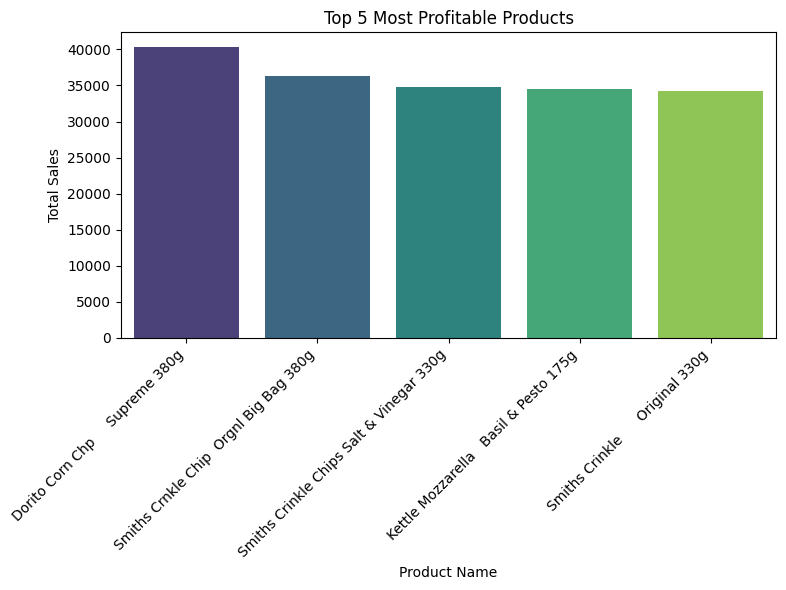

In [81]:
prod_sales = merged_df.groupby(["PROD_NBR", "PROD_NAME"])["TOT_SALES"].sum().reset_index()
top_prod = prod_sales.sort_values(by="TOT_SALES", ascending=False).head(5)
print("\nTop 5 Most Profitable Products:")
print(tabulate(top_prod, headers="keys", tablefmt="pretty"))


plt.figure(figsize=(8, 6))
sns.barplot(data=top_prod, x="PROD_NAME", y="TOT_SALES", palette="viridis")
plt.title('Top 5 Most Profitable Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finding Loyal Customers



Top 5 Most Loyal Customer Segments:
+----+-----------------------+------------------+--------------------+
|    |       LIFESTAGE       | PREMIUM_CUSTOMER | TOTAL_TRANSACTIONS |
+----+-----------------------+------------------+--------------------+
| 6  |    OLDER FAMILIES     |      Budget      |       23160        |
| 13 |       RETIREES        |    Mainstream    |       21466        |
| 19 | YOUNG SINGLES/COUPLES |    Mainstream    |       20854        |
| 15 |    YOUNG FAMILIES     |      Budget      |       19122        |
| 9  | OLDER SINGLES/COUPLES |      Budget      |       18407        |
+----+-----------------------+------------------+--------------------+


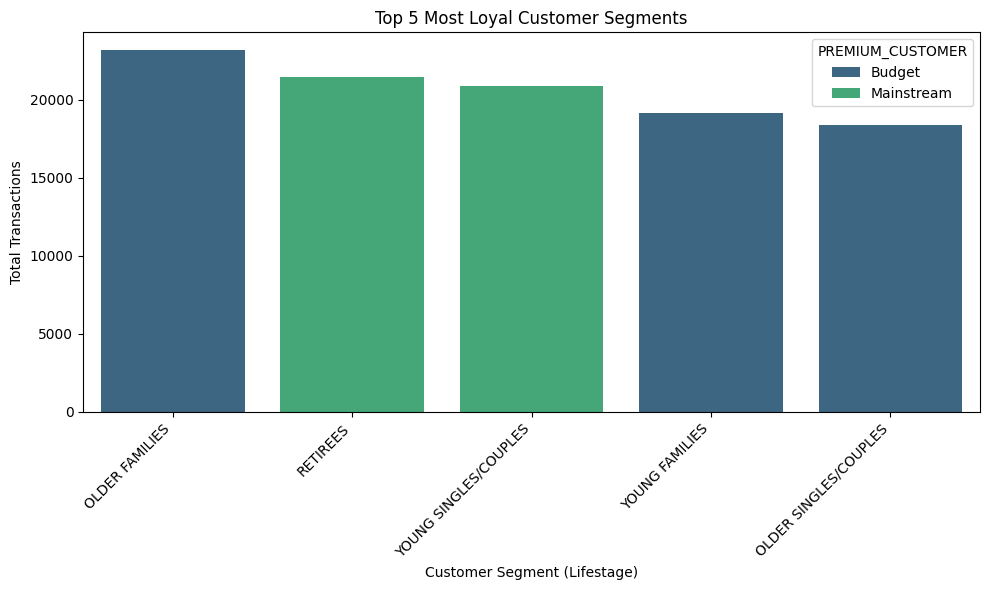

In [82]:
cust_loyalty = merged_df.groupby("LYLTY_CARD_NBR")["TXN_ID"].count().reset_index()
cust_loyalty.columns = ["LYLTY_CARD_NBR", "TOTAL_TRANSACTIONS"]

loyal_cust = cust_loyalty.merge(pb_df, on="LYLTY_CARD_NBR", how="left")

loyalty_by_segment = loyal_cust.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOTAL_TRANSACTIONS"].sum().reset_index()

top_loyal_segments = loyalty_by_segment.sort_values(by="TOTAL_TRANSACTIONS", ascending=False).head(5)

print("\nTop 5 Most Loyal Customer Segments:")
print(tabulate(top_loyal_segments, headers="keys", tablefmt="pretty"))


plt.figure(figsize=(10, 6))
sns.barplot(data=top_loyal_segments, x="LIFESTAGE", y="TOTAL_TRANSACTIONS", hue="PREMIUM_CUSTOMER", palette="viridis")
plt.title('Top 5 Most Loyal Customer Segments')
plt.xlabel('Customer Segment (Lifestage)')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature Extraction

In [83]:
cust_spent = merged_df.groupby("LYLTY_CARD_NBR")["TOT_SALES"].sum().reset_index()
cust_spent.columns = ["LYLTY_CARD_NBR", "TOTAL_SPENT"]
cust_spent["AVG_SPENT_PER_TRANSACTION"] = cust_spent["TOTAL_SPENT"] / cust_loyalty["TOTAL_TRANSACTIONS"]
merged_df["DATE"] = pd.to_datetime(merged_df["DATE"])
cust_count = merged_df.groupby("LYLTY_CARD_NBR")["DATE"].agg(lambda x: (x.max() - x.min()).days).reset_index()
cust_count.columns = ["LYLTY_CARD_NBR", "FREQUENCY_OF_PURCHASES"]
loyal_cust = loyal_cust.merge(cust_spent, on="LYLTY_CARD_NBR", how="left")
loyal_cust = loyal_cust.merge(cust_count, on="LYLTY_CARD_NBR", how="left")
median_transactions = loyal_cust["TOTAL_TRANSACTIONS"].median()
loyal_cust["LOYALTY_LABEL"] = (loyal_cust["TOTAL_TRANSACTIONS"] > median_transactions).astype(int)

Encoding categorical data

In [84]:
label_encoders = {}
for col in ["LIFESTAGE", "PREMIUM_CUSTOMER"]:
    le = LabelEncoder()
    loyal_cust[col] = le.fit_transform(loyal_cust[col])
    label_encoders[col] = le

Training the model

In [85]:
X = loyal_cust[["LIFESTAGE", "PREMIUM_CUSTOMER", "TOTAL_SPENT", "AVG_SPENT_PER_TRANSACTION", "FREQUENCY_OF_PURCHASES"]]
y = loyal_cust["LOYALTY_LABEL"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluation Metrics

In [86]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(f"\nModel Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(tabulate(report_df, headers="keys", tablefmt="pretty"))


Model Accuracy: 1.00

Classification Report:
+--------------+--------------------+--------------------+--------------------+--------------------+
|              |     precision      |       recall       |      f1-score      |      support       |
+--------------+--------------------+--------------------+--------------------+--------------------+
|      0       | 0.9998789492797482 |        1.0         | 0.9999394709763332 |       8260.0       |
|      1       |        1.0         | 0.9998404594767071 | 0.9999202233745512 |       6268.0       |
|   accuracy   | 0.9999311674008811 | 0.9999311674008811 | 0.9999311674008811 | 0.9999311674008811 |
|  macro avg   | 0.9999394746398741 | 0.9999202297383536 | 0.9999298471754422 |      14528.0       |
| weighted avg | 0.9999311757331167 | 0.9999311674008811 | 0.9999311667384497 |      14528.0       |
+--------------+--------------------+--------------------+--------------------+--------------------+
